In [59]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/NVDA/NVDA.USUSD_Candlestick_1_D_ASK_05.10.2022-05.10.2024.csv")
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
df = df.iloc[0:300]

df["open"] = df.Open.astype(float)
df["high"] = df.High.astype(float)
df["low"] = df.Low.astype(float)
df["close"] = df.Close.astype(float)

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.high, low=df.low, close=df.close)
df["atr"] = df.atr.rolling(window=30).mean()
df.reset_index(drop=True, inplace=True)

df

,Gmt time,Open,High,Low,Close,Volume,open,high,low,close,atr
0,2022-10-04 21:00:00,128.934,133.204,126.263,131.964,68.6664,128.934,133.204,126.263,131.964,NaN
1,2022-10-05 21:00:00,132.503,136.583,131.074,131.343,102.7296,132.503,136.583,131.074,131.343,NaN
2,2022-10-06 21:00:00,125.134,126.704,120.253,120.924,90.6384,125.134,126.704,120.253,120.924,NaN
3,2022-10-07 21:00:00,120.924,120.924,120.924,120.924,0.0000,120.924,120.924,120.924,120.924,NaN
4,2022-10-08 21:00:00,120.924,120.924,120.924,120.924,0.0000,120.924,120.924,120.924,120.924,NaN
...,...,...,...,...,...,...,...,...,...,...,...
295,2023-07-26 21:00:00,465.013,474.004,457.604,459.143,68.1180,465.013,474.004,457.604,459.143,9.762428
296,2023-07-27 21:00:00,466.753,470.324,464.143,467.613,54.8688,466.753,470.324,464.143,467.613,9.784605
297,2023-07-28 21:00:00,467.613,467.613,467.613,467.613,0.0000,467.613,467.613,467.613,467.613,9.781628
298,2023-07-29 21:00:00,467.613,467.613,467.613,467.613,0.0000,467.613,467.613,467.613,467.613,9.738362


# Plotting Price Data

In [60]:
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from IPython import display
from IPython.display import HTML
pd.set_option('mode.chained_assignment', None)

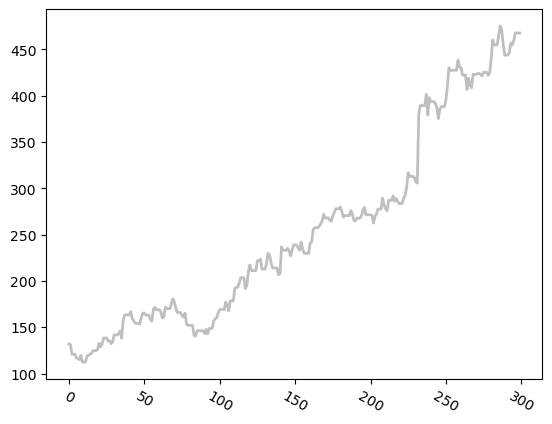

In [61]:
df2 = df.iloc[0:300]

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.close, c='grey', lw=2, alpha=0.5, zorder=5)

plt.show()

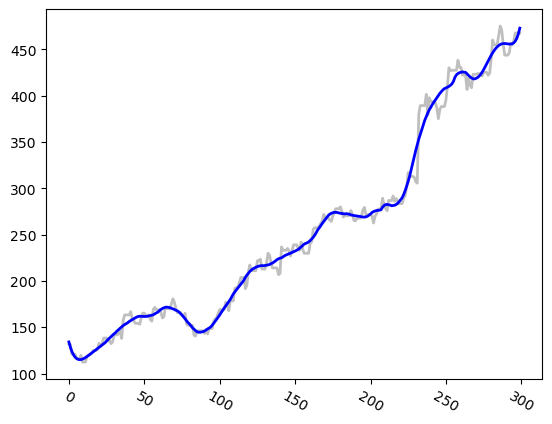

In [63]:
df2 = df.iloc[0:300]

df2["close_smooth"] = savgol_filter(df2.close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

plt.show()

#  Detecting Extrema

[ 68 237 256 284]


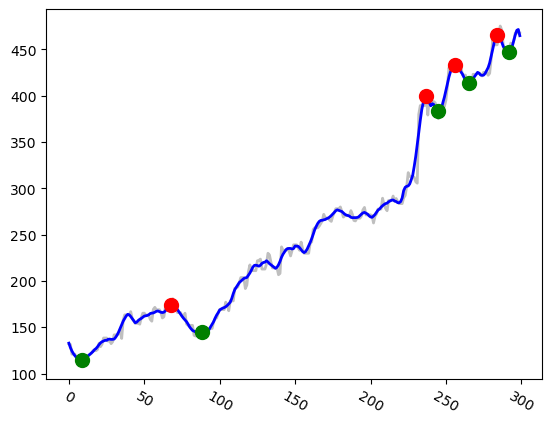

In [64]:
df2 = df.iloc[0:300]

df2["close_smooth"] = savgol_filter(df2.close, 20, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 10, width = 3, prominence=atr)

print(peaks_idx)

troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 10, width = 3, prominence=atr)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

plt.show()

# Finding Runs

[ 68 237 256 284]
[  9  88 245 265 292]
3


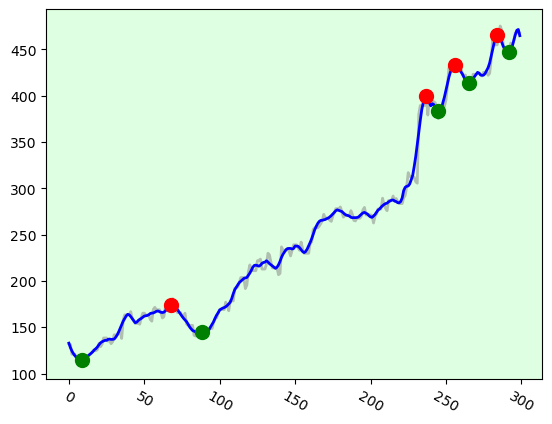

In [65]:
df2 = df.iloc[0:300]

df2["close_smooth"] = savgol_filter(df2.close, 20, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 10, width = 3, prominence=atr)
troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 10, width = 3, prominence=atr)

print(peaks_idx)
print(troughs_idx)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)


up_run_length = 0
up_run = True
while up_run:
    
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break
        
    if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
       df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
        up_run_length += 1
    else:
        up_run = False    
          

if up_run_length > 0:
    ax.set_facecolor((150/255, 255/255, 159/255, 0.3))  
else:
    ax.set_facecolor("white")
        
print(up_run_length)

plt.show()